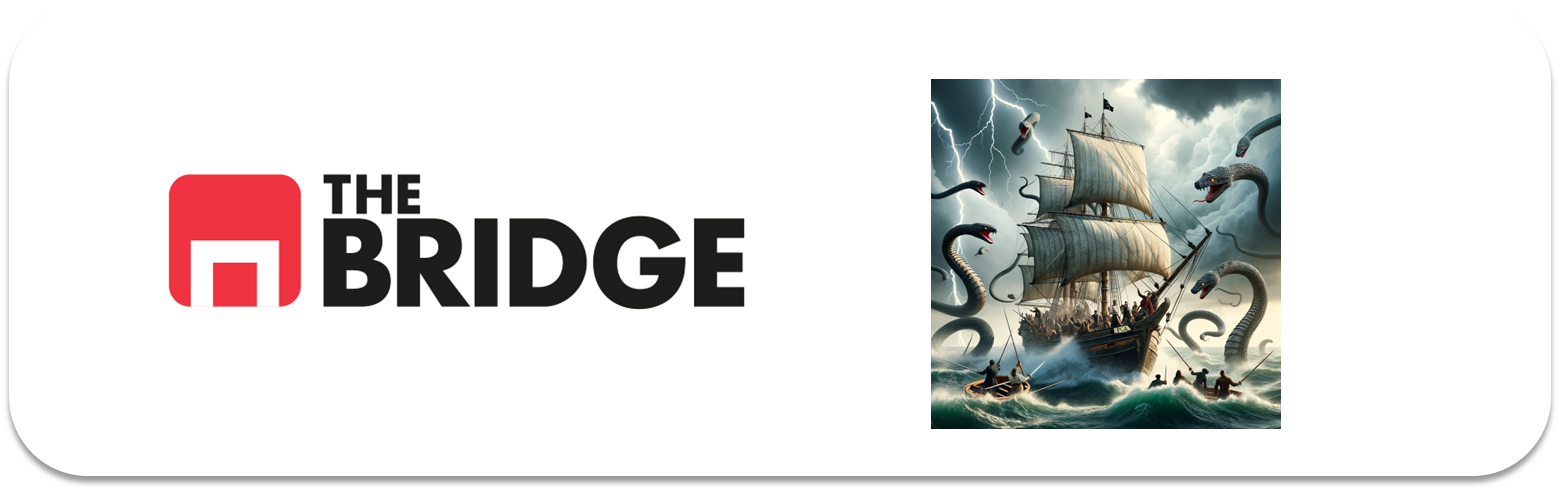

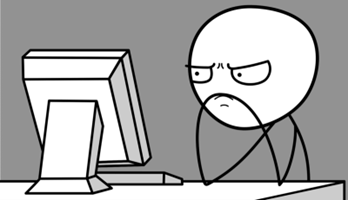

Para ejercitarte y afianzar lo aprendido sobre **Seleccion de Features**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

## Feature selection: Breast Cancer Winsconsin

El objetivo de este grupo de ejercicio es dar a entender la importancia de la selección de características (features), así como probar distintos métodos de reducción de características (features) y qué influencia puede tener el reducir features en el perfomance de un modelo. Nuestro target para evaluar el perfomance será si estamos ante tumores malignos o benignos.

Vamos a trabajar con el dataset de Breast Cancer Winsconsin, datos tomados a partir de radiografías.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Ejercicio 1:

Carga los datos y haz una primera inspección de los mismos y comenta lo que creas conveniente sobre las features y su relación entre sí (pero sin analizarlas numéricamente)

In [2]:
df = pd.read_csv('./data/breastcancer-winsconsin.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

### Ejercicio 2:

Descarta las características que evidentemente no aportan información.

In [4]:
df = df.drop(columns=['Unnamed: 32'])
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
df = df.set_index('id')
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820


### Ejercicio 3: 

Divide en train y test. Analiza el target de forma breve.

In [6]:
X = df.drop(columns="diagnosis")
y = df["diagnosis"]

In [7]:
y.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

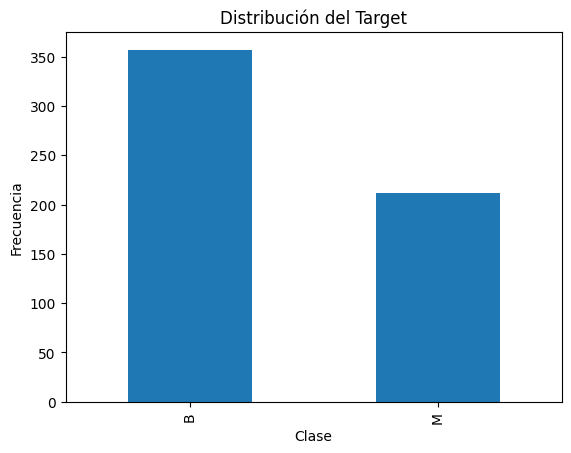

In [8]:
pd.Series(y).value_counts().plot(kind="bar")
plt.title("Distribución del Target")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show();

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify= y
)

### Ejercicio 4: MiniEDA (I) Análisis Visual

Realiza un análisis visual de las features y haz tu selección de primera "división" (que luego usaremos para comparar con otros métodos de selección).

In [10]:
cat_cols = X_train.select_dtypes(include=["category", "object"]).columns
cat_cols

Index([], dtype='str')

In [11]:
num_cols = X_train.select_dtypes(include=["number"]).columns
num_cols

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

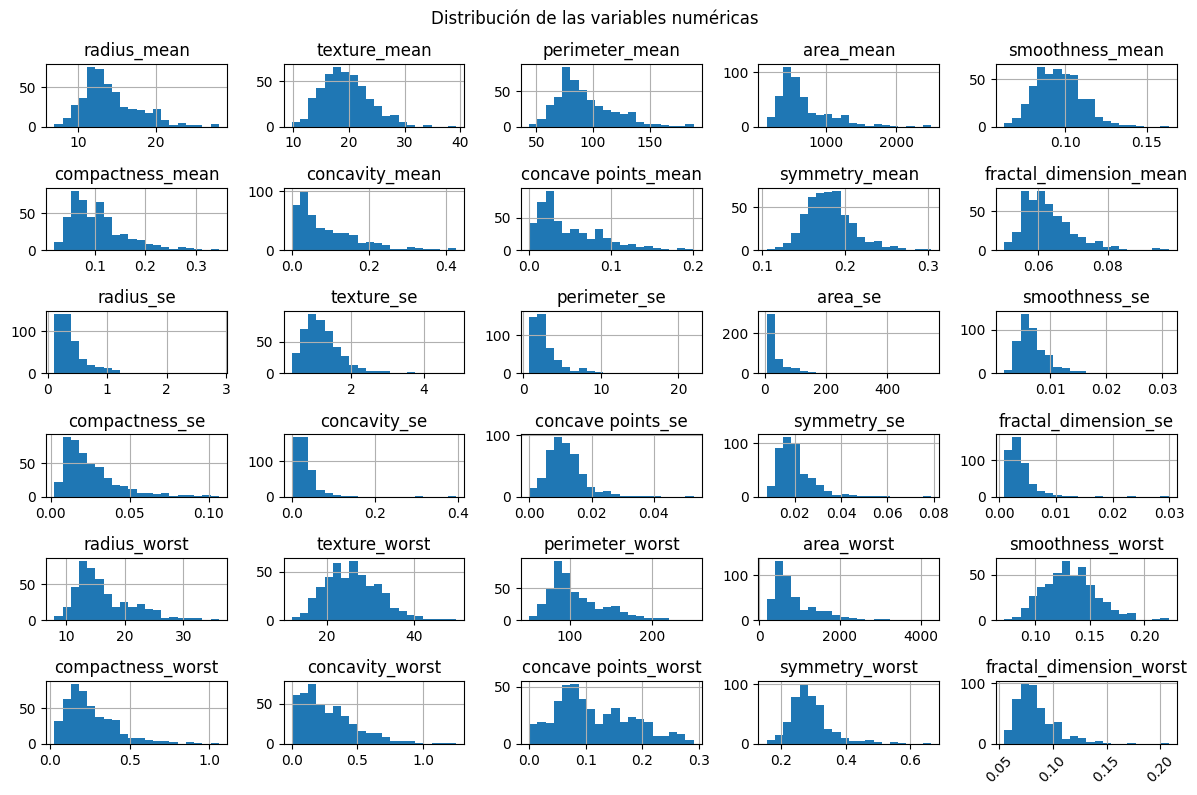

In [12]:
X_train[num_cols].hist(figsize=(12,8), bins = 20)
plt.suptitle("Distribución de las variables numéricas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();


In [13]:
X_train[num_cols].corr()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.326358,0.997815,0.986740,0.188805,0.526901,0.676323,0.826984,0.148416,-0.294777,...,0.969256,0.303891,0.964439,0.940515,0.124912,0.417638,0.515938,0.741073,0.151632,0.010712
texture_mean,0.326358,1.000000,0.331800,0.318811,-0.011749,0.246818,0.292341,0.289028,0.089454,-0.068576,...,0.350573,0.911671,0.356590,0.336349,0.075855,0.282338,0.289614,0.288636,0.114120,0.126669
perimeter_mean,0.997815,0.331800,1.000000,0.985960,0.225840,0.577536,0.716044,0.855414,0.185686,-0.244184,...,0.969332,0.309888,0.970006,0.941085,0.155970,0.460088,0.553325,0.768021,0.178037,0.053990
area_mean,0.986740,0.318811,0.985960,1.000000,0.200033,0.518185,0.685587,0.827092,0.154040,-0.264658,...,0.960725,0.290117,0.956714,0.958177,0.133316,0.393840,0.501422,0.717781,0.131099,0.008730
smoothness_mean,0.188805,-0.011749,0.225840,0.200033,1.000000,0.668208,0.540455,0.570760,0.558946,0.592764,...,0.243269,0.060610,0.269934,0.237707,0.824095,0.492120,0.453733,0.531333,0.415142,0.509334
compactness_mean,0.526901,0.246818,0.577536,0.518185,0.668208,1.000000,0.892790,0.845809,0.608154,0.560300,...,0.559706,0.264249,0.615411,0.530403,0.569264,0.867360,0.820215,0.828208,0.512286,0.675986
concavity_mean,0.676323,0.292341,0.716044,0.685587,0.540455,0.892790,1.000000,0.920598,0.514502,0.358402,...,0.688777,0.296746,0.731725,0.675319,0.452000,0.759892,0.878816,0.857881,0.410384,0.521660
concave points_mean,0.826984,0.289028,0.855414,0.827092,0.570760,0.845809,0.920598,1.000000,0.479263,0.183271,...,0.838067,0.298276,0.864362,0.815747,0.458986,0.676361,0.746509,0.912250,0.384501,0.372876
symmetry_mean,0.148416,0.089454,0.185686,0.154040,0.558946,0.608154,0.514502,0.479263,1.000000,0.496995,...,0.195371,0.115193,0.231960,0.186780,0.440022,0.480185,0.434807,0.448602,0.706311,0.447477
fractal_dimension_mean,-0.294777,-0.068576,-0.244184,-0.264658,0.592764,0.560300,0.358402,0.183271,0.496995,1.000000,...,-0.230020,-0.037014,-0.179904,-0.209438,0.517282,0.473458,0.375302,0.202556,0.358654,0.771813


### Ejercicio 5

Observa correlaciones entre las features. Utiliza un gráfico apropiado para ello. ¿Crees que sea posible eliminar algunas features para mejorar el modelo? (No hace falta que lo hagas ahora, lo haremos si es necesario en un ejercicio posterior)

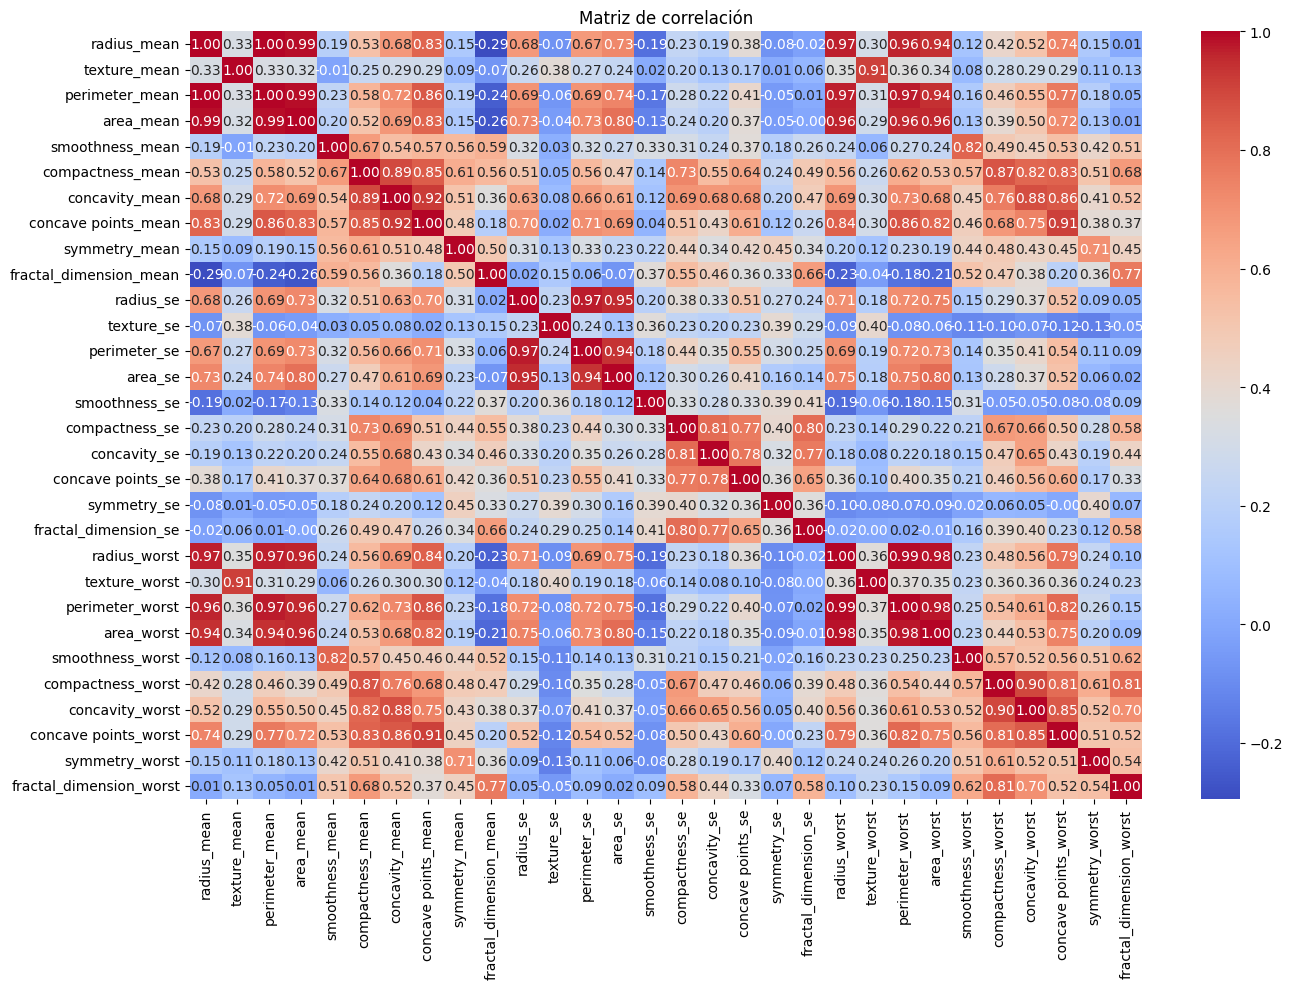

In [14]:
plt.figure(figsize=(14, 10))
sns.heatmap(X_train[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show();

In [ ]:
# Podemos observar una alta correlación entre variables terminando con _worst, lo que sugiere una posible multicolinealidad entre ellas
# Por lo que puede seer información redundante

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


### Ejercicio 6:

Entrena (con validación cruzada) un modelo de RandomForestClassifier (con max_depth a 5) con todas las features (ojo incluso las que descartamos en el ejercicio 4) y guarda el perfomance ("balanced_accuracy") en test en una variable. Será nuestro base line de comparación

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score 

In [18]:
rf_base = RandomForestClassifier(max_depth = 5, random_state = 42)

cv_scores = cross_val_score(
    rf_base,
    X_train,
    y_train,
    cv = 5,
    scoring = "balanced_accuracy"
)

rf_base.fit(X_train, y_train)
y_pred = rf_base.predict(X_test)

In [20]:
baseline_bal_acc = balanced_accuracy_score(y_test, y_pred)
print("Baseline Balanced Accuracy Score:", baseline_bal_acc)

Baseline Balanced Accuracy Score: 0.9642857142857143


Dado que el baseline ya presenta un rendimiento alto, el objetivo no será necesariamente superarlo, sino comprobar si es posible mantener un rendimiento similar utilizando un menor número de variables. Esto puede ser útil en contextos reales donde reducir features disminuye costes de almacenamiento y procesamiento, simplifica el mantenimiento del modelo y mejora su interpretabilidad ante equipos de negocio o stakeholders.

### Ejercicio 7

Vamos a emplear nuestras features del análisis visual pero descartando variables correladas entre sí (emplea la matriz ya obtenida en el ejercicio 5 o bien cualquier medio que creas conveniente). Descarta features y muestra la matriz de correlación para la selección final (recuerda, parte de la lista creada en el ejercicio 4)

In [21]:
X_train.columns

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

In [23]:
selected_features = [
    'radius_mean', 
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean',
    'fractal_dimension_mean'
    ]

matriz_corr_abs = X_train[selected_features].corr().abs()
matriz_corr_abs

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
radius_mean,1.000000,0.326358,0.997815,0.986740,0.188805,0.526901,0.676323,0.826984,0.148416,0.294777
texture_mean,0.326358,1.000000,0.331800,0.318811,0.011749,0.246818,0.292341,0.289028,0.089454,0.068576
perimeter_mean,0.997815,0.331800,1.000000,0.985960,0.225840,0.577536,0.716044,0.855414,0.185686,0.244184
area_mean,0.986740,0.318811,0.985960,1.000000,0.200033,0.518185,0.685587,0.827092,0.154040,0.264658
smoothness_mean,0.188805,0.011749,0.225840,0.200033,1.000000,0.668208,0.540455,0.570760,0.558946,0.592764
compactness_mean,0.526901,0.246818,0.577536,0.518185,0.668208,1.000000,0.892790,0.845809,0.608154,0.560300
concavity_mean,0.676323,0.292341,0.716044,0.685587,0.540455,0.892790,1.000000,0.920598,0.514502,0.358402
concave points_mean,0.826984,0.289028,0.855414,0.827092,0.570760,0.845809,0.920598,1.000000,0.479263,0.183271
symmetry_mean,0.148416,0.089454,0.185686,0.154040,0.558946,0.608154,0.514502,0.479263,1.000000,0.496995
fractal_dimension_mean,0.294777,0.068576,0.244184,0.264658,0.592764,0.560300,0.358402,0.183271,0.496995,1.000000


In [25]:
upper = matriz_corr_abs.where(np.triu(np.ones(matriz_corr_abs.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

Features descartadas: ['perimeter_mean', 'area_mean', 'concave points_mean']
Features finales: ['radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean']


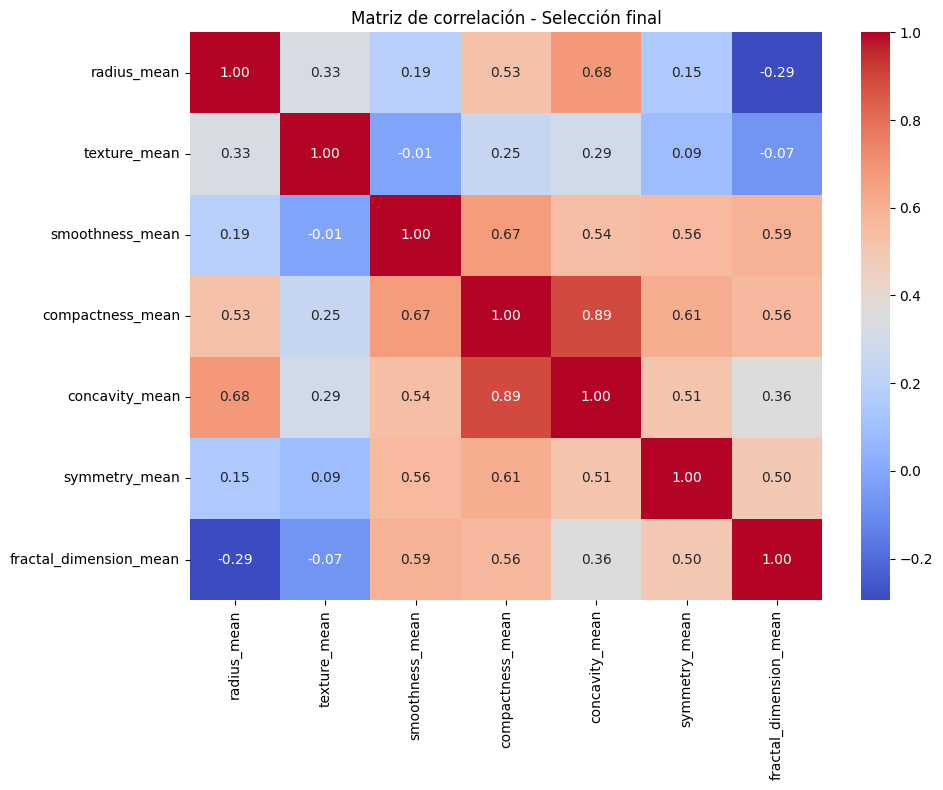

In [26]:
selected_features_final = [col for col in selected_features if col not in to_drop]

print("Features descartadas:", to_drop)
print("Features finales:", selected_features_final)

# Heatmap final
plt.figure(figsize=(10, 8))
sns.heatmap(X_train[selected_features_final].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación - Selección final")
plt.tight_layout()
plt.show();

In [28]:
X_train_sel = X_train[selected_features_final]
X_test_sel = X_test[selected_features_final]

### Ejercicio 8

Evalúa tu primer feature reduction. Entrena un modelo y evalúa su perfomance con los features que seleccionaste en el ejercicio anterios (emplea la validación cruzada)

In [30]:
rf_selected = RandomForestClassifier(max_depth = 5, random_state = 42)

cv_score_selected = cross_val_score(
    rf_selected,
    X_train_sel,
    y_train,
    cv = 5,
    scoring = "balanced_accuracy"
)

print("CV Balanced Accuracy:", cv_score_selected.mean())

CV Balanced Accuracy: 0.9424148606811145


In [31]:
rf_selected.fit(X_train_sel, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [32]:
y_pred_selected = rf_selected.predict(X_test_sel)

selected_bal_acc = balanced_accuracy_score(y_test, y_pred_selected)

print("Test Balanced Accuracy Score:", selected_bal_acc)

Test Balanced Accuracy Score: 0.9384920634920635


### Ejercicio 9

Prueba ahora a hacer una feature selection utilizando ANOVA. Compara la validación cruzada con la del modelo baseline y con la del modelo anterior. (Pista: SelectKbest)

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

pipe_anova = Pipeline([
    ("select", SelectKBest(score_func = f_classif, k = 10)),
    ("model", RandomForestClassifier(max_depth = 5, random_state = 42))
])

cv_scores_anova = cross_val_score(
    pipe_anova,
    X_train,
    y_train,
    cv = 5,
    scoring = "balanced_accuracy"
)

print("CV Balanced Accuracy (ANOVA):", cv_scores_anova.mean())

CV Balanced Accuracy (ANOVA): 0.9353973168214654


El modelo con selección de características mediante ANOVA (SelectKBest con f_classif, k=10) obtuvo un balanced_accuracy medio en validación cruzada de 0.9354. Este resultado sugiere que, aunque la selección mantiene un rendimiento bueno, queda por debajo del modelo baseline, por lo que esta reducción de variables no parece mejorar el comportamiento del modelo en este caso.

In [36]:
pipe_anova.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('select', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...t 0x122280400>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",10
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fraction

In [37]:
y_pred_anova = pipe_anova.predict(X_test)

anova_bal_acc = balanced_accuracy_score(y_test, y_pred_anova)
print("Test Balanced Accuracy (ANOVA):", anova_bal_acc)

Test Balanced Accuracy (ANOVA): 0.9404761904761905


### Ejercicio 10

Prueba a hacer ahora una selección de features con RFE (Recursive Feature Elimination), hasta quedarte con 5 features. Evalúa perfomance en "balanced_accuracy" con cross_validation y compara con la baseline.

In [39]:
from sklearn.feature_selection import RFE

pipe_rfe = Pipeline([
    ("select", RFE(
        estimator = RandomForestClassifier(max_depth = 5, random_state = 42),
        n_features_to_select = 5
    )),
    ("model", RandomForestClassifier(max_depth = 5, random_state = 42))
])

cross_scores_rfe = cross_val_score(
    pipe_rfe,
    X_train,
    y_train,
    cv = 5,
    scoring = "balanced_accuracy"
)

print("CV Balanced Accuracy (RFE) Mean:", cross_scores_rfe.mean())

CV Balanced Accuracy (RFE) Mean: 0.9353973168214654


In [40]:
pipe_rfe.fit(X_train, y_train)
y_pred_rfe = pipe_rfe.predict(X_test)

rfe_bal_acc = balanced_accuracy_score(y_test, y_pred_rfe)
print("Test Balanced Accuracy (RFE):", rfe_bal_acc)

Test Balanced Accuracy (RFE): 0.9315476190476191


### Ejercicio 11

Prueba a eliminar features con el modelo de RandomForestClassifier (emplea SelectFromModel de sklearn). Utiliza esta vez una regresión logística para entrenar con las features escogidas y compara con el baseline. Muestra primero la importancia obtenida con el modelo baseline (que básicamente es el mismo que vamos a usar con SelectFromModel). Prueba primero para features por encima de la mediana y luego para las 5 primeras.

In [41]:
importances = pd.Series(rf_base.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print(importances)

area_worst                 0.152915
concave points_worst       0.134546
radius_worst               0.100371
perimeter_worst            0.087629
concave points_mean        0.083709
perimeter_mean             0.077532
radius_mean                0.059437
concavity_mean             0.051643
area_mean                  0.044947
concavity_worst            0.030722
area_se                    0.022708
radius_se                  0.016456
texture_worst              0.015983
compactness_worst          0.015885
texture_mean               0.014803
smoothness_worst           0.014751
compactness_mean           0.011966
symmetry_worst             0.011351
perimeter_se               0.008026
fractal_dimension_worst    0.006211
concavity_se               0.005093
compactness_se             0.005087
fractal_dimension_se       0.005064
symmetry_mean              0.004212
smoothness_mean            0.004070
fractal_dimension_mean     0.004007
texture_se                 0.003532
symmetry_se                0

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

pipe_sfm_top5 = Pipeline([
    ("select", SelectFromModel(
        RandomForestClassifier(max_depth = 5, random_state = 42),
        threshold = -np.inf,
        max_features = 5
    )),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter = 1000, random_state = 42))
])

cross_scores_sfm_top5 = cross_val_score(
    pipe_sfm_top5,
    X_train,
    y_train,
    cv = 5,
    scoring = "balanced_accuracy"
)

print("CV Balanced Score Mean (SFM - Top 5 + Log. Reg.):", cross_scores_sfm_top5.mean())

CV Balanced Score Mean (SFM - Top 5 + Log. Reg.): 0.9307017543859649


In [44]:
pipe_sfm_top5.fit(X_train, y_train)

y_pred_sfm_top5 = pipe_sfm_top5.predict(X_test)

sfm_top5_bal_acc = balanced_accuracy_score(y_test, y_pred_sfm_top5)
print("Test Balanced Accuracy (SFM top 5 + Logistic):", sfm_top5_bal_acc)

Test Balanced Accuracy (SFM top 5 + Logistic): 0.9503968253968254


In [45]:
pipe_sfm_median = Pipeline([
    ("select", SelectFromModel(
        RandomForestClassifier(max_depth=5, random_state=42),
        threshold="median"
    )),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores_sfm_median = cross_val_score(
    pipe_sfm_median,
    X_train,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

print("CV Balanced Accuracy (SFM median):", cv_scores_sfm_median.mean())

pipe_sfm_median.fit(X_train, y_train)
y_pred_sfm_median = pipe_sfm_median.predict(X_test)

sfm_median_bal_acc = balanced_accuracy_score(y_test, y_pred_sfm_median)
print("Test Balanced Accuracy (SFM median):", sfm_median_bal_acc)

CV Balanced Accuracy (SFM median): 0.9600619195046439
Test Balanced Accuracy (SFM median): 0.9692460317460317


In [46]:
features_sfm_median = X_train.columns[pipe_sfm_median.named_steps["select"].get_support()]
print("Features seleccionadas (median):", features_sfm_median)

Features seleccionadas (median): Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'concavity_mean', 'concave points_mean', 'radius_se', 'area_se',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst'],
      dtype='str')


In [47]:
print(f"Baseline test: {baseline_bal_acc:.4f}")
print(f"SFM median test: {sfm_median_bal_acc:.4f}")
print(f"SFM top 5 test: {sfm_top5_bal_acc:.4f}")

Baseline test: 0.9643
SFM median test: 0.9692
SFM top 5 test: 0.9504


El modelo baseline obtuvo un balanced_accuracy en test de 0.9643.
Al aplicar SelectFromModel con un RandomForestClassifier y conservar las variables con importancia por encima de la mediana, la LogisticRegression alcanzó un resultado de 0.9692, ligeramente superior al baseline. Esto sugiere que eliminar variables menos relevantes o redundantes puede incluso mejorar el rendimiento del modelo.

En cambio, al limitar la selección a solo las 5 variables más importantes, el rendimiento bajó a 0.9504. Aunque sigue siendo un resultado alto, indica que una reducción demasiado agresiva puede provocar pérdida de información útil.

### Ejercicio EXTRA:

Investiga RFECV y obten el número optimo de features siguiendo esta técnica pero con el "balanced_accuracy" como métrica.